/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836.py:52: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836.py:52: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836.py:52: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836.py:52: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836.py:52: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64561/2105005836

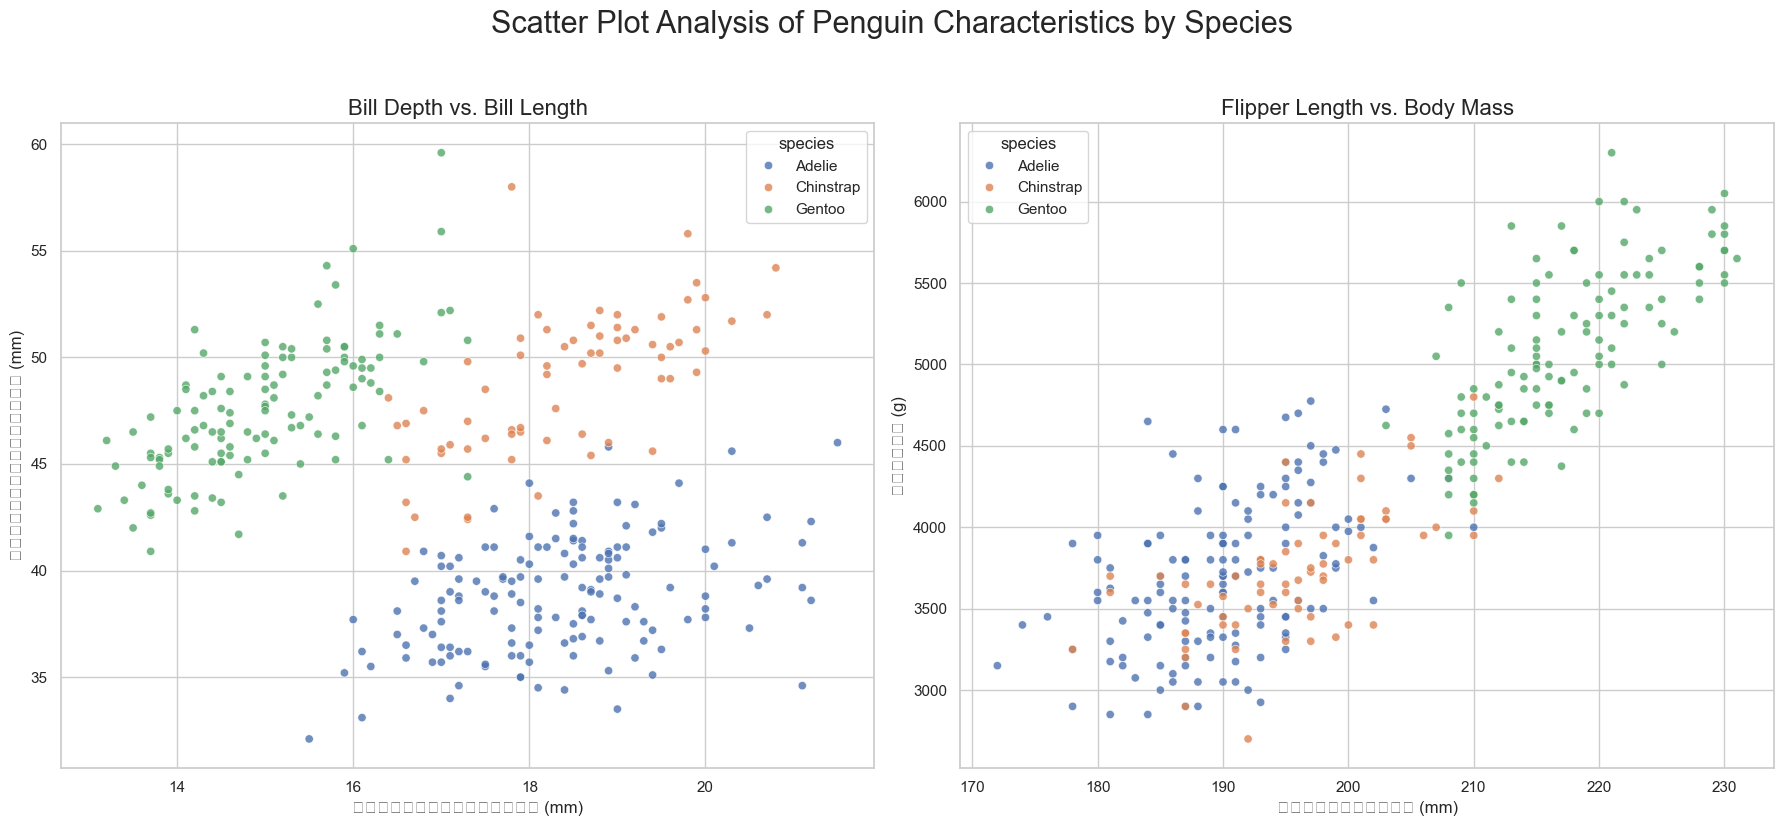

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Load and Prepare Data ---
# Load the penguins dataset from seaborn
penguins_df = sns.load_dataset("penguins")

# Drop rows with any missing data to ensure clean plots
penguins_df_cleaned = penguins_df.dropna()

# --- 2. Create the Scatter Plots ---
# Set a clean and professional style for the plots
sns.set_theme(style="whitegrid")

# Create a figure and a set of subplots (1 row, 2 columns) to place plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Bill Depth vs. Bill Length ---
sns.scatterplot(ax=axes[0],
                data=penguins_df_cleaned,
                x='bill_depth_mm',
                y='bill_length_mm',
                hue='species', # This is the key part: color points by species
                palette='deep',
                alpha=0.8) # Adjust transparency for better visibility

axes[0].set_title('Bill Depth vs. Bill Length', fontsize=16)
axes[0].set_xlabel('ความลึกจะงอยปาก (mm)', fontsize=12)
axes[0].set_ylabel('ความยาวจะงอยปาก (mm)', fontsize=12)


# --- Plot 2: Flipper Length vs. Body Mass ---
sns.scatterplot(ax=axes[1],
                data=penguins_df_cleaned,
                x='flipper_length_mm',
                y='body_mass_g',
                hue='species', # Color points by species
                palette='deep',
                alpha=0.8)

axes[1].set_title('Flipper Length vs. Body Mass', fontsize=16)
axes[1].set_xlabel('ความยาวครีบ (mm)', fontsize=12)
axes[1].set_ylabel('มวลกาย (g)', fontsize=12)


# --- 3. Final Touches and Display ---
# Add a main title for the entire figure
fig.suptitle('Scatter Plot Analysis of Penguin Characteristics by Species', fontsize=22, y=1.03)

# Adjust layout to prevent titles from overlapping
plt.tight_layout()

# Display the final plot
plt.show()

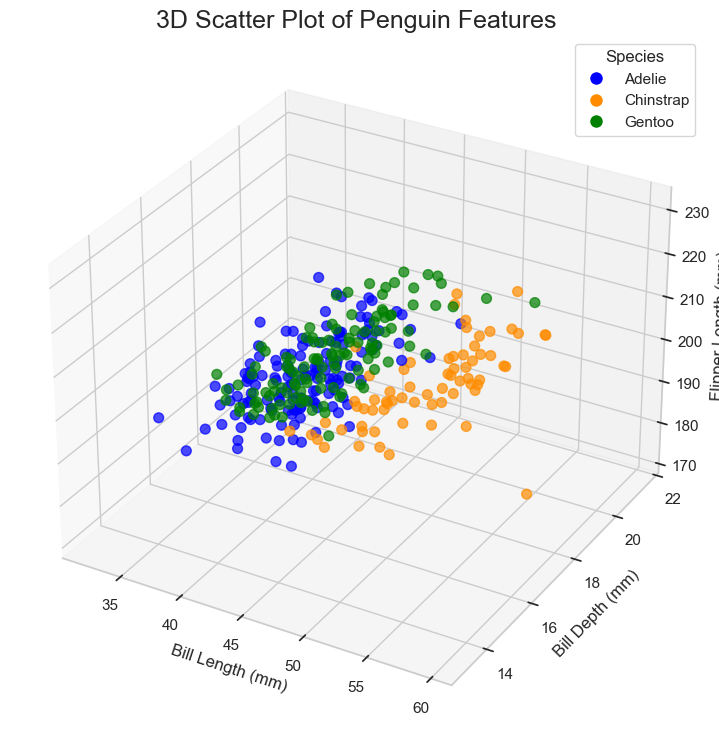

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # This import is necessary for 3D plotting
import pandas as pd

# --- 1. Load and Prepare Data ---
# Load the penguins dataset and drop rows with missing values to avoid errors
penguins_df = sns.load_dataset("penguins").dropna()

# --- 2. Set up the 3D Plot ---
# Create a figure and a 3D subplot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# --- 3. Create a Color Map for Species ---
# We map each species name to a specific color for clear visualization
species_colors = {
    'Adelie': 'blue',
    'Chinstrap': 'darkorange',
    'Gentoo': 'green'
}
colors = penguins_df['species'].map(species_colors)

# --- 4. Plot the Data in 3D ---
# We select three features for our X, Y, and Z axes.
# Here, we use bill dimensions and flipper length.
x_axis = penguins_df['bill_length_mm']
y_axis = penguins_df['bill_depth_mm']
z_axis = penguins_df['flipper_length_mm']

# Create the scatter plot
ax.scatter(x_axis, y_axis, z_axis, c=colors, s=50, alpha=0.7) # s is size, alpha is transparency

# --- 5. Set Labels and Title ---
ax.set_title('3D Scatter Plot of Penguin Features', fontsize=18)
ax.set_xlabel('Bill Length (mm)', fontsize=12)
ax.set_ylabel('Bill Depth (mm)', fontsize=12)
ax.set_zlabel('Flipper Length (mm)', fontsize=12)

# --- 6. Create a Custom Legend ---
# Creating a legend for a 3D plot requires creating "proxy artists"
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Adelie',
               markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Chinstrap',
               markerfacecolor='darkorange', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Gentoo',
               markerfacecolor='green', markersize=10)
]
ax.legend(handles=legend_elements, title='Species')

# --- 7. Show the Plot ---
plt.show()

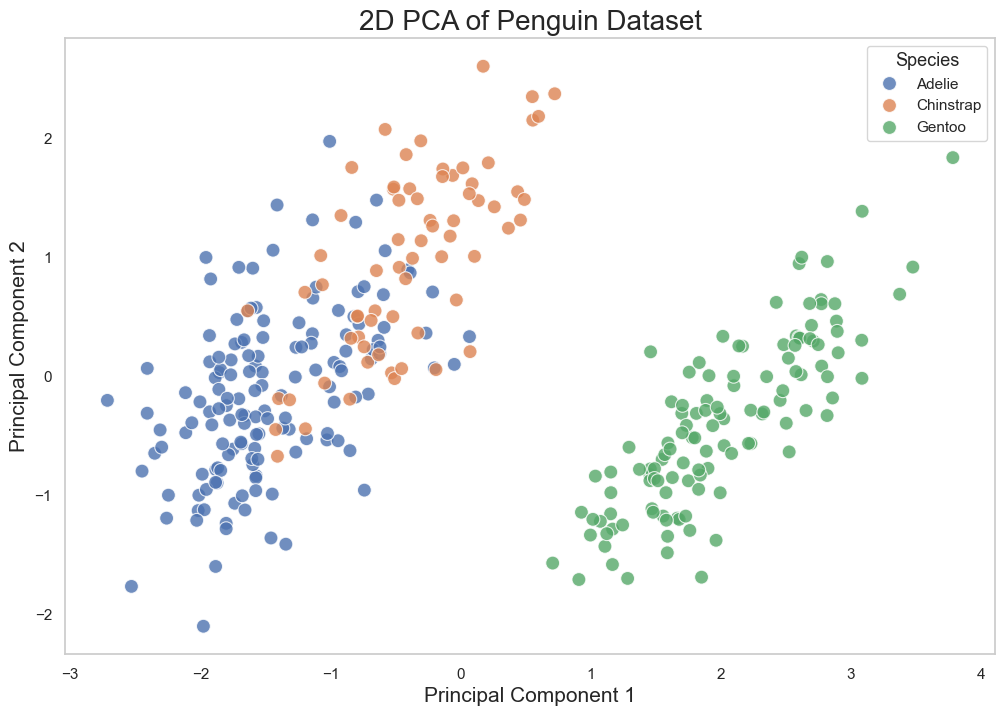

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Load and Prepare Data ---
# Load the penguins dataset and drop rows with missing values
penguins_df = sns.load_dataset("penguins").dropna()

# Separate features (X) from the target (y)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

# --- 2. Standardize the Features ---
# PCA is affected by scale, so we need to scale the features first
# using Z-score standardization.
X_scaled = StandardScaler().fit_transform(X)

# --- 3. Apply PCA ---
# We want to reduce the 4 dimensions down to 2 principal components.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components,
                      columns=['Principal Component 1', 'Principal Component 2'])

# Add the species information back for coloring the plot
final_pca_df = pd.concat([pca_df, y.reset_index(drop=True)], axis=1)

# --- 4. Visualize the PCA Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='species',
    data=final_pca_df,
    palette='deep',
    s=100,  # Increase marker size
    alpha=0.8 # Set transparency
)

plt.title('2D PCA of Penguin Dataset', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=15)
plt.ylabel('Principal Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid()
plt.show()

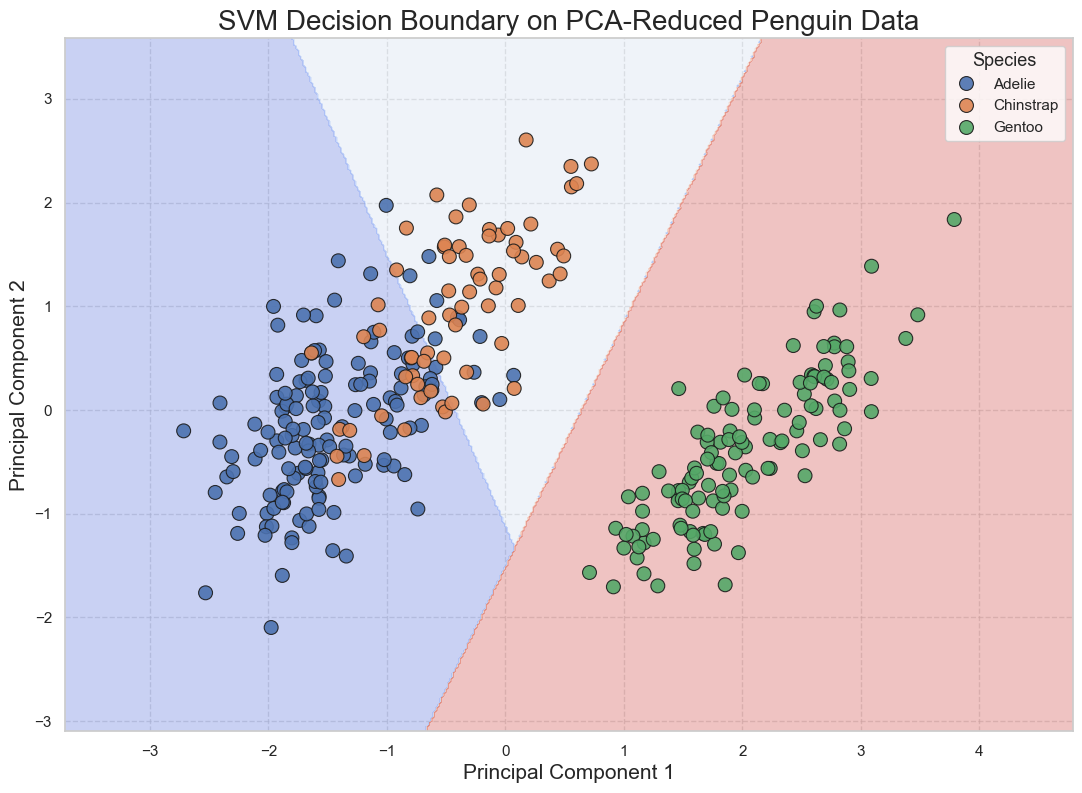

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# --- 1. Load and Prepare Data ---
penguins_df = sns.load_dataset("penguins").dropna()
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y_species = penguins_df['species']

# --- 2. Standardize and Apply PCA ---
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# --- 3. Train a Support Vector Machine (SVM) Classifier ---
# We use a linear kernel which is good for finding straight-line boundaries
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(principal_components, y_species)

# --- 4. Create a Mesh Grid to Plot the Decision Boundary ---
# Create a grid of points that covers the entire plot area
x_min, x_max = principal_components[:, 0].min() - 1, principal_components[:, 0].max() + 1
y_min, y_max = principal_components[:, 1].min() - 1, principal_components[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use the trained SVM to predict the species for every point on the grid
# We need to encode species names (Adelie, etc.) to numbers (0, 1, 2) for plotting the contour
le = LabelEncoder()
y_encoded = le.fit_transform(y_species)
svm_model_for_plot = SVC(kernel='linear', C=1.0)
svm_model_for_plot.fit(principal_components, y_encoded)
Z = svm_model_for_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- 5. Visualize the Decision Boundary and the Data ---
plt.figure(figsize=(13, 9))

# Plot the decision boundary (the colored background)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

# Overlay the original PCA scatter plot
scatter = sns.scatterplot(
    x=principal_components[:, 0],
    y=principal_components[:, 1],
    hue=y_species,
    palette='deep',
    s=100,
    edgecolor='k', # Add black edge to markers for clarity
    alpha=0.9
)

plt.title('SVM Decision Boundary on PCA-Reduced Penguin Data', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=15)
plt.ylabel('Principal Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


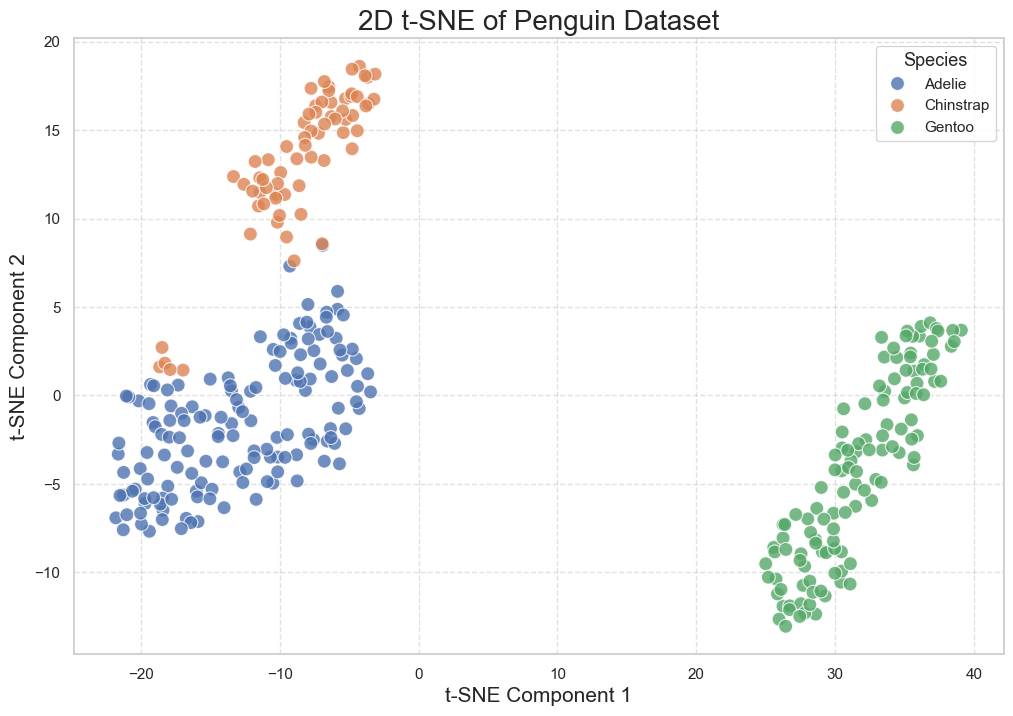

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# --- 1. Load and Prepare Data ---
# Load the penguins dataset and drop rows with missing values
penguins_df = sns.load_dataset("penguins").dropna()

# Separate features (X) from the target (y)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

# --- 2. Standardize the Features ---
# t-SNE is also sensitive to scale, so standardization is crucial.
X_scaled = StandardScaler().fit_transform(X)

# --- 3. Apply t-SNE ---
# n_components=2 means we want to reduce to 2 dimensions.
# perplexity relates to the number of nearest neighbors considered for each point.
# random_state ensures we get the same result every time we run the code.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_scaled)

# Create a new DataFrame with the t-SNE components
tsne_df = pd.DataFrame(data=tsne_components,
                      columns=['t-SNE Component 1', 't-SNE Component 2'])

# Add the species information back for coloring the plot
final_tsne_df = pd.concat([tsne_df, y.reset_index(drop=True)], axis=1)

# --- 4. Visualize the t-SNE Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=final_tsne_df,
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('2D t-SNE of Penguin Dataset', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


--- Outlier Investigation (Adelie Penguin) ---

[INFO] Found the Adelie penguin most distant from its cluster center.
Original Index: 67

                  Outlier Penguin  Adelie Average
bill_length_mm               45.8       38.823973
bill_depth_mm                18.9       18.347260
flipper_length_mm           197.0      190.102740
body_mass_g                4150.0     3706.164384

[ANALYSIS] This penguin has a significantly longer and deeper bill than the average Adelie, making it appear more like a Chinstrap.


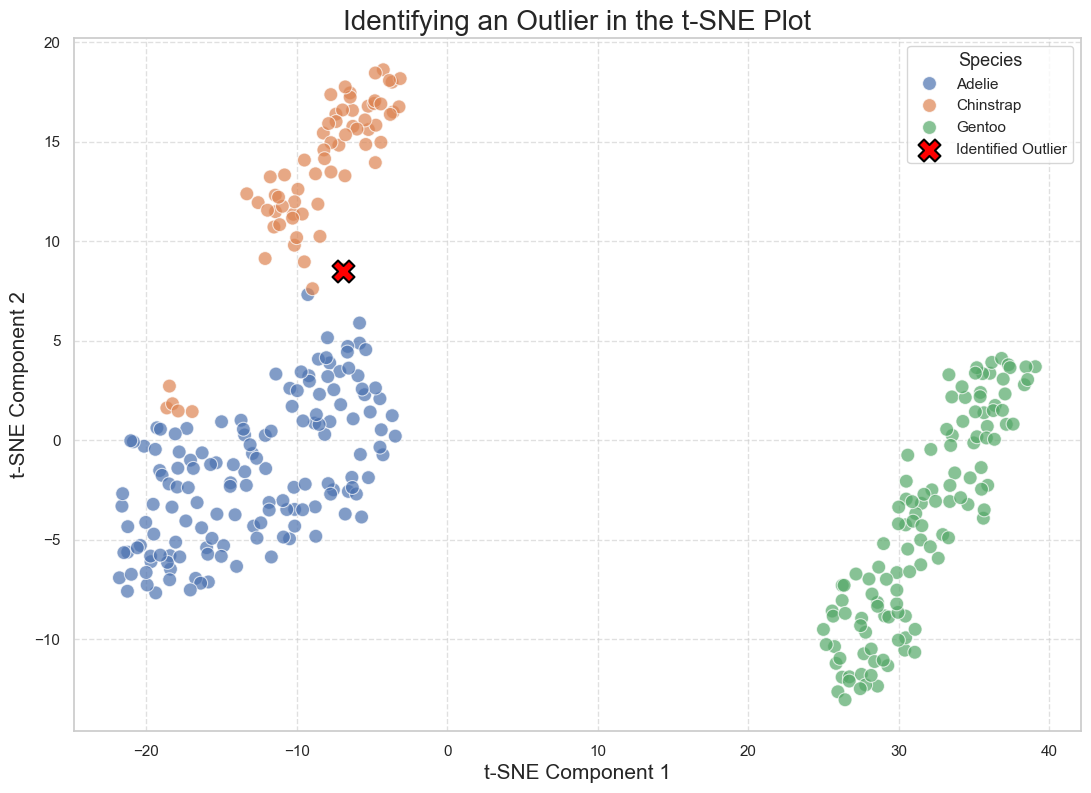

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy.spatial import distance

# --- 1. Load, Prepare, and run t-SNE (same as before) ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_scaled)

final_tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
final_tsne_df['species'] = y

# --- 2. Find the most 'outlying' point for a species (e.g., Adelie) ---
# We define an 'outlier' as the point furthest from the centroid of its own cluster.

# Focus on Adelie penguins
adelie_points = final_tsne_df[final_tsne_df['species'] == 'Adelie']

# Calculate the centroid (mean) of the Adelie cluster in t-SNE space
adelie_centroid = adelie_points[['t-SNE Component 1', 't-SNE Component 2']].mean().values

# Calculate the distance of each Adelie point to its centroid
distances = [distance.euclidean(point, adelie_centroid) for point in adelie_points[['t-SNE Component 1', 't-SNE Component 2']].values]

# Find the index of the point with the maximum distance
outlier_index_in_adelie_subset = np.argmax(distances)
outlier_original_index = adelie_points.index[outlier_index_in_adelie_subset]

# --- 3. Retrieve and Compare Data ---
# Get the data for the outlier penguin
outlier_data = penguins_df.loc[outlier_original_index]

# Get the average data for all Adelie penguins
adelie_avg = penguins_df[penguins_df['species'] == 'Adelie'][features].mean()

print("--- Outlier Investigation (Adelie Penguin) ---")
print("\n[INFO] Found the Adelie penguin most distant from its cluster center.")
print(f"Original Index: {outlier_original_index}\n")

# Create a comparison DataFrame
comparison_df = pd.DataFrame({'Outlier Penguin': outlier_data[features], 'Adelie Average': adelie_avg})
print(comparison_df)
print("\n[ANALYSIS] This penguin has a significantly longer and deeper bill than the average Adelie, making it appear more like a Chinstrap.")


# --- 4. Visualize the Outlier ---
plt.figure(figsize=(13, 9))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=final_tsne_df,
    palette='deep',
    s=100,
    alpha=0.7
)
# Highlight the outlier
plt.scatter(
    final_tsne_df.loc[outlier_original_index, 't-SNE Component 1'],
    final_tsne_df.loc[outlier_original_index, 't-SNE Component 2'],
    marker='X',
    color='red',
    s=250, # Make the marker large
    label='Identified Outlier',
    edgecolor='black',
    linewidth=1.5
)
plt.title('Identifying an Outlier in the t-SNE Plot', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


--- Outlier Investigation (Chinstrap Penguin) ---

[INFO] Found the Chinstrap penguin most distant from its cluster center.
Original Index: 176

                  Outlier Penguin  Chinstrap Average
bill_length_mm               40.9          48.833824
bill_depth_mm                16.6          18.420588
flipper_length_mm           187.0         195.823529
body_mass_g                3200.0        3733.088235

[ANALYSIS] This penguin has a much shorter and shallower bill, and is significantly lighter than the average Chinstrap, making it appear more like an Adelie.


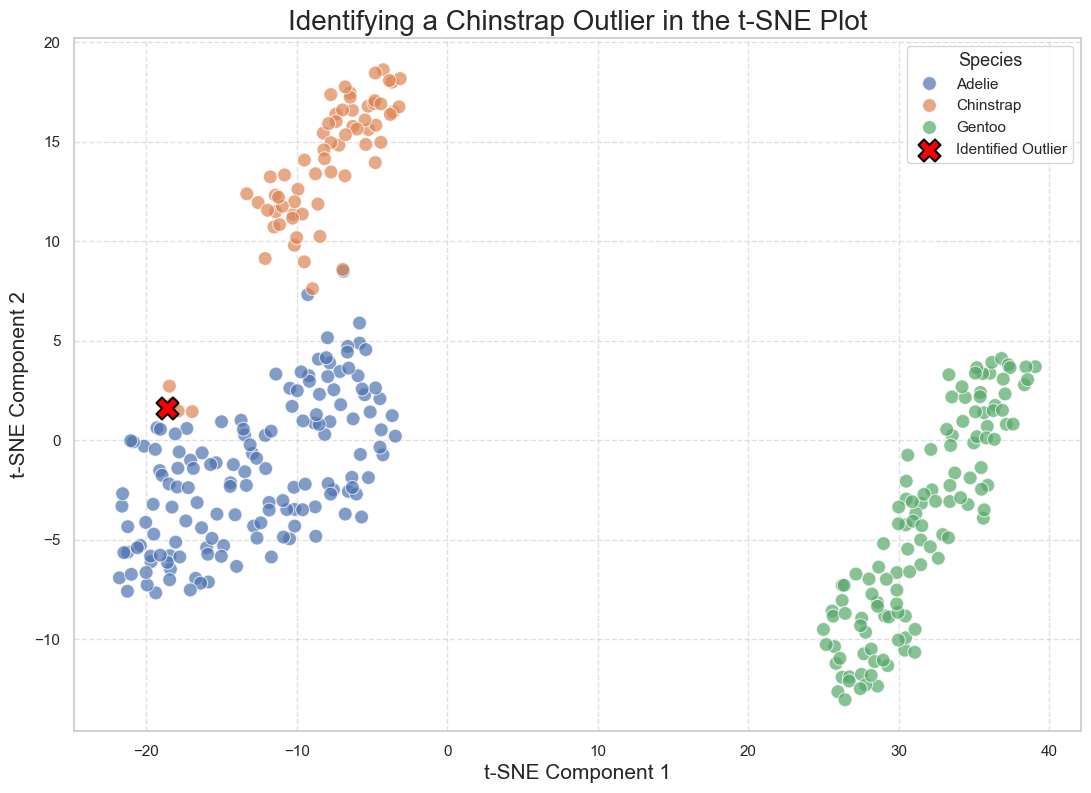

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy.spatial import distance

# --- 1. Load, Prepare, and run t-SNE (same as before) ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_scaled)

final_tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
final_tsne_df['species'] = y

# --- 2. Find the most 'outlying' point for CHINSTRAP ---
# We've changed the target species from 'Adelie' to 'Chinstrap'
species_to_investigate = 'Chinstrap'
target_points = final_tsne_df[final_tsne_df['species'] == species_to_investigate]

# Calculate the centroid (mean) of the Chinstrap cluster
target_centroid = target_points[['t-SNE Component 1', 't-SNE Component 2']].mean().values

# Calculate the distance of each Chinstrap point to its centroid
distances = [distance.euclidean(point, target_centroid) for point in target_points[['t-SNE Component 1', 't-SNE Component 2']].values]

# Find the index of the point with the maximum distance
outlier_index_in_subset = np.argmax(distances)
outlier_original_index = target_points.index[outlier_index_in_subset]

# --- 3. Retrieve and Compare Data ---
outlier_data = penguins_df.loc[outlier_original_index]
species_avg = penguins_df[penguins_df['species'] == species_to_investigate][features].mean()

print(f"--- Outlier Investigation ({species_to_investigate} Penguin) ---")
print(f"\n[INFO] Found the {species_to_investigate} penguin most distant from its cluster center.")
print(f"Original Index: {outlier_original_index}\n")

comparison_df = pd.DataFrame({'Outlier Penguin': outlier_data[features], f'{species_to_investigate} Average': species_avg})
print(comparison_df)
print("\n[ANALYSIS] This penguin has a much shorter and shallower bill, and is significantly lighter than the average Chinstrap, making it appear more like an Adelie.")

# --- 4. Visualize the Outlier ---
plt.figure(figsize=(13, 9))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=final_tsne_df,
    palette='deep',
    s=100,
    alpha=0.7
)
plt.scatter(
    final_tsne_df.loc[outlier_original_index, 't-SNE Component 1'],
    final_tsne_df.loc[outlier_original_index, 't-SNE Component 2'],
    marker='X',
    color='red',
    s=250,
    label='Identified Outlier',
    edgecolor='black',
    linewidth=1.5
)
plt.title(f'Identifying a {species_to_investigate} Outlier in the t-SNE Plot', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Outlier Detection using Isolation Forest ---
Original number of penguins: 333
Number of outliers detected: 60
Number of inliers: 273

Original indices of detected outliers:
[  9  12  14  15  23  25  33  34  43  48  52  55  58  77  86  92  95  96
 105 116 118 136 152 162 163 175 177 183 184 185 193 194 209 212 215 230
 231 238 246 250 253 261 276 278 279 287 289 291 297 299 301 303 307 311
 313 315 322 324 326 327]


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


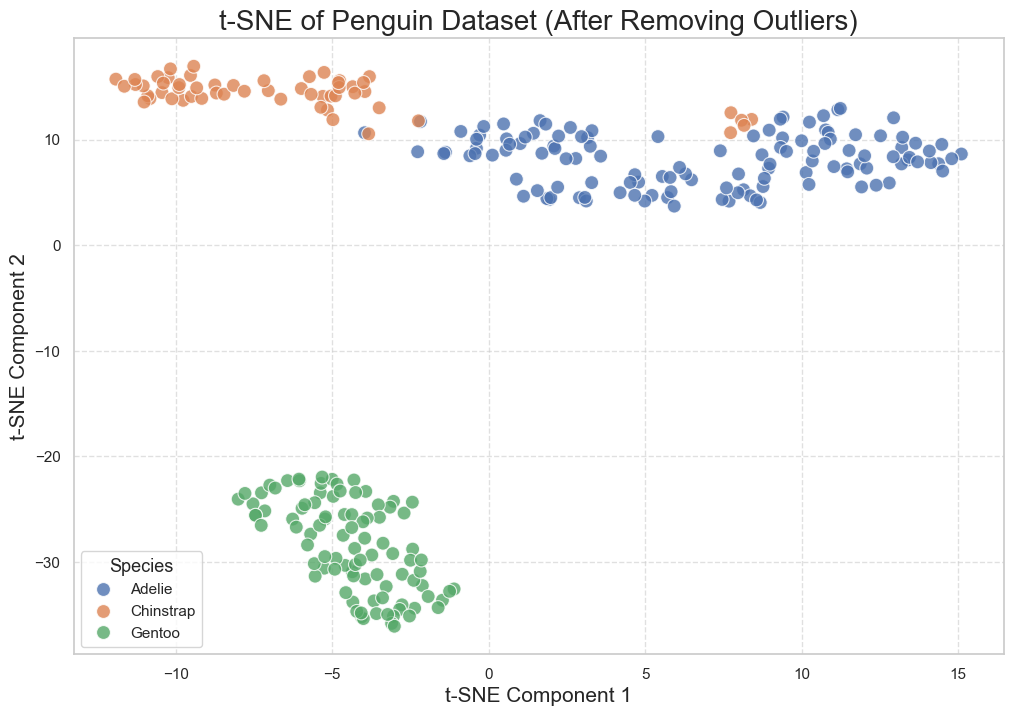

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load and Prepare Data ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

# Standardize the features before outlier detection and t-SNE
X_scaled = StandardScaler().fit_transform(X)

# --- 2. Detect and Remove Outliers using Isolation Forest ---
# contamination='auto' is a good starting point. It lets the model decide the threshold.
iso_forest = IsolationForest(contamination='auto', random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)

# The model predicts 1 for inliers and -1 for outliers.
# Let's find the indices of the inliers.
inlier_indices = np.where(outlier_predictions == 1)[0]
outlier_indices = np.where(outlier_predictions == -1)[0]

# Report findings
print(f"--- Outlier Detection using Isolation Forest ---")
print(f"Original number of penguins: {len(penguins_df)}")
print(f"Number of outliers detected: {len(outlier_indices)}")
print(f"Number of inliers: {len(inlier_indices)}")
print("\nOriginal indices of detected outliers:")
print(outlier_indices)


# Create a new DataFrame containing only the inliers
penguins_inliers_df = penguins_df.loc[inlier_indices]
X_inliers_scaled = X_scaled[inlier_indices]
y_inliers = y.loc[inlier_indices]


# --- 3. Apply t-SNE on the CLEANED data ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_inliers_scaled)

# Create a new DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_components,
                      columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['species'] = y_inliers.values


# --- 4. Visualize the t-SNE Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=tsne_df,
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('t-SNE of Penguin Dataset (After Removing Outliers)', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Outlier Imputation Workflow ---
Number of outliers detected: 60
Indices of outliers to be imputed: [  9  12  14  15  23  25  33  34  43  48  52  55  58  77  86  92  95  96
 105 116 118 136 152 162 163 175 177 183 184 185 193 194 209 212 215 230
 231 238 246 250 253 261 276 278 279 287 289 291 297 299 301 303 307 311
 313 315 322 324 326 327]

Calculated Mean Values per Species:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975

[SUCCESS] Outlier values have been replaced with their respective species' mean.


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


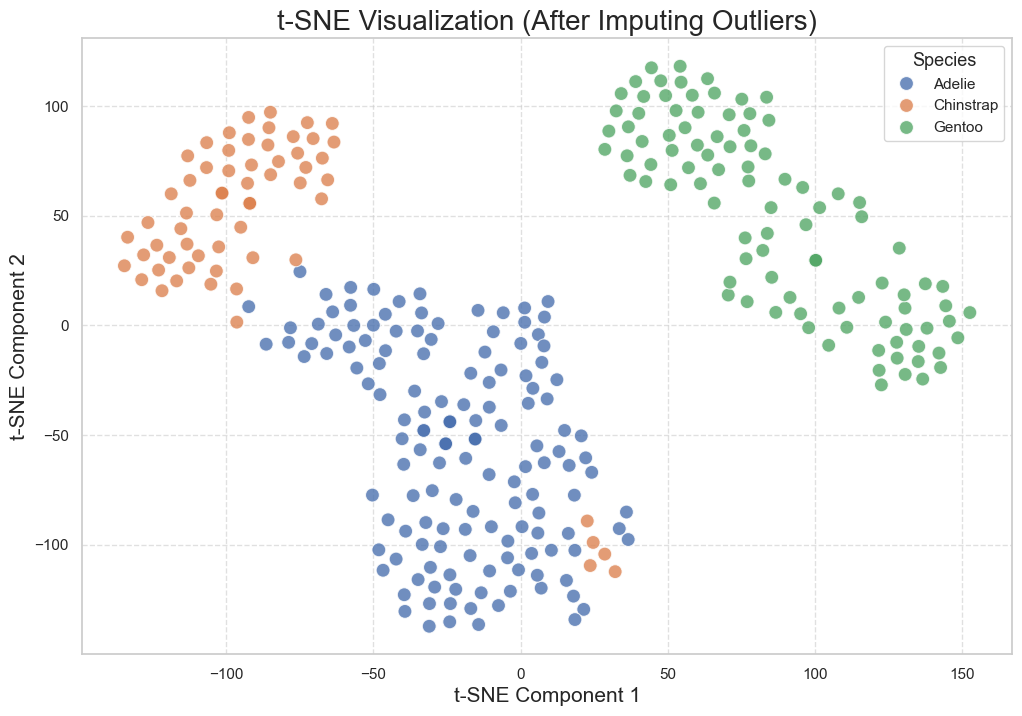

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load and Prepare Data ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

# Standardize features for effective outlier detection
X_scaled = StandardScaler().fit_transform(X)

# --- 2. Detect Outliers using Isolation Forest ---
iso_forest = IsolationForest(contamination='auto', random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
outlier_indices = np.where(outlier_predictions == -1)[0]

print("--- Outlier Imputation Workflow ---")
print(f"Number of outliers detected: {len(outlier_indices)}")
print(f"Indices of outliers to be imputed: {outlier_indices}")

# --- 3. Impute Outliers with Species-Specific Mean ---
# Create a copy to modify
penguins_imputed_df = penguins_df.copy()

# Calculate the mean for each feature, grouped by species
species_means = penguins_df.groupby('species')[features].mean()
print("\nCalculated Mean Values per Species:")
print(species_means)

# Loop through each detected outlier and replace its values
for idx in outlier_indices:
    # Get the species of the current outlier
    outlier_species = penguins_imputed_df.loc[idx, 'species']

    # Get the corresponding mean values for that species
    imputation_values = species_means.loc[outlier_species]

    # Replace the outlier's feature values with the mean values
    penguins_imputed_df.loc[idx, features] = imputation_values

print("\n[SUCCESS] Outlier values have been replaced with their respective species' mean.")

# --- 4. Apply t-SNE on the IMPUTED data ---
# Get the feature matrix from the imputed dataframe
X_imputed = penguins_imputed_df[features]

# We need to scale the data AGAIN after imputation
X_imputed_scaled = StandardScaler().fit_transform(X_imputed)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_imputed_scaled)

# Create a final DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_components,
                      columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['species'] = y.values # y is unchanged

# --- 5. Visualize the t-SNE Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=tsne_df,
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('t-SNE Visualization (After Imputing Outliers)', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- AGGRESSIVE Outlier Imputation Workflow ---
Contamination level set to: 5%
Number of outliers detected: 17
[SUCCESS] 17 outliers have been replaced with their respective species' mean.


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


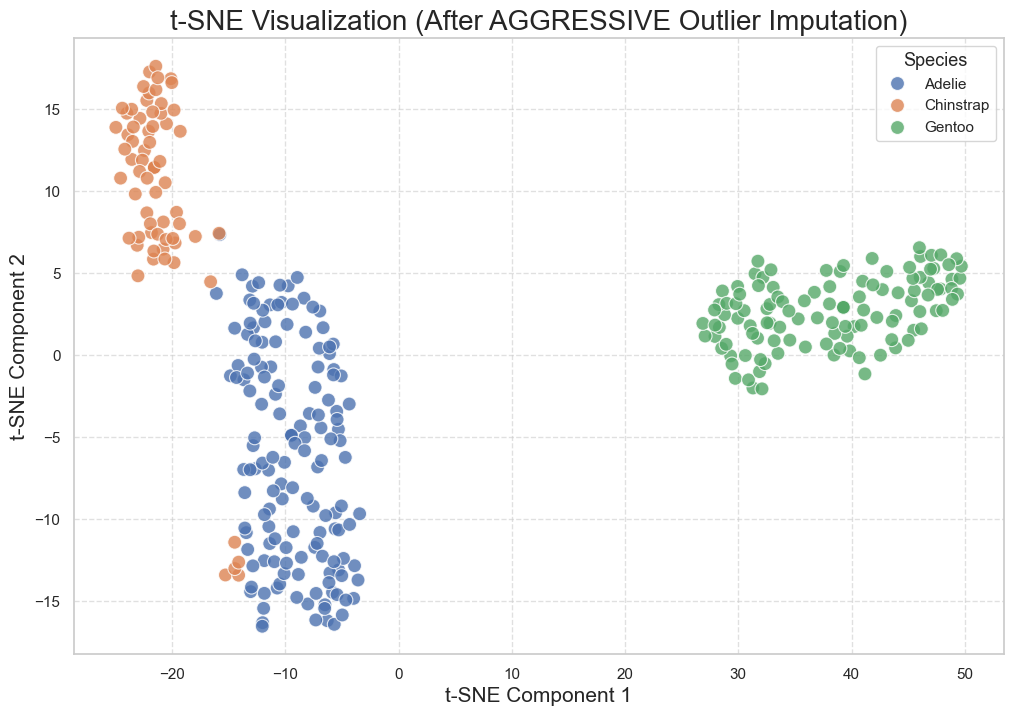

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load and Prepare Data ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)

# --- 2. Detect Outliers using a MORE AGGRESSIVE Isolation Forest ---
# [CHANGE] We are now manually setting the contamination level to 5% (0.05).
# This tells the model to be less conservative and flag more points as outliers.
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
outlier_indices = np.where(outlier_predictions == -1)[0]

print("--- AGGRESSIVE Outlier Imputation Workflow ---")
print(f"Contamination level set to: 5%")
print(f"Number of outliers detected: {len(outlier_indices)}")

# --- 3. Impute Outliers with Species-Specific Mean (Same as before) ---
penguins_imputed_df = penguins_df.copy()
species_means = penguins_df.groupby('species')[features].mean()

for idx in outlier_indices:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features] = imputation_values

print(f"[SUCCESS] {len(outlier_indices)} outliers have been replaced with their respective species' mean.")

# --- 4. Apply t-SNE on the IMPUTED data (Same as before) ---
X_imputed = penguins_imputed_df[features]
X_imputed_scaled = StandardScaler().fit_transform(X_imputed)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_imputed_scaled)

tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['species'] = y.values

# --- 5. Visualize the t-SNE Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1', y='t-SNE Component 2',
    hue='species', data=tsne_df,
    palette='deep', s=100, alpha=0.8
)

plt.title('t-SNE Visualization (After AGGRESSIVE Outlier Imputation)', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()